### Section 1: Data and Setup

____
**Import numpy and pandas**

In [1]:
import pandas as pd
import numpy as np

**Import visualization libraries and set %matplotlib inline.**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**Read in the csv file as a dataframe called df**

In [3]:
df = pd.read_csv(r"C:\Users\LUPHEN\Desktop\Cleaned_Dataset\3MTT_Project_Dataset\911.csv")
#Top ten overview of the dataframe.
df.head(10)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,12/10/2015 17:10,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,12/10/2015 17:29,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,12/10/2015 14:39,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,12/10/2015 16:47,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,12/10/2015 16:56,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1
5,40.253473,-75.283245,CANNON AVE & W 9TH ST; LANSDALE; Station 345;...,19446.0,EMS: HEAD INJURY,12/10/2015 15:39,LANSDALE,CANNON AVE & W 9TH ST,1
6,40.182111,-75.127795,LAUREL AVE & OAKDALE AVE; HORSHAM; Station 35...,19044.0,EMS: NAUSEA/VOMITING,12/10/2015 16:46,HORSHAM,LAUREL AVE & OAKDALE AVE,1
7,40.217286,-75.405182,COLLEGEVILLE RD & LYWISKI RD; SKIPPACK; Stati...,19426.0,EMS: RESPIRATORY EMERGENCY,12/10/2015 16:17,SKIPPACK,COLLEGEVILLE RD & LYWISKI RD,1
8,40.289027,-75.399590,MAIN ST & OLD SUMNEYTOWN PIKE; LOWER SALFORD;...,19438.0,EMS: SYNCOPAL EPISODE,12/10/2015 16:51,LOWER SALFORD,MAIN ST & OLD SUMNEYTOWN PIKE,1
9,40.102398,-75.291458,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD; PLYM...,19462.0,Traffic: VEHICLE ACCIDENT -,12/10/2015 17:35,PLYMOUTH,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD,1


**Check the info() of the df**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663522 entries, 0 to 663521
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        663522 non-null  float64
 1   lng        663522 non-null  float64
 2   desc       663522 non-null  object 
 3   zip        583323 non-null  float64
 4   title      663522 non-null  object 
 5   timeStamp  663522 non-null  object 
 6   twp        663229 non-null  object 
 7   addr       663522 non-null  object 
 8   e          663522 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 45.6+ MB


**Check the head of df**

In [5]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,12/10/2015 17:10,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,12/10/2015 17:29,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,12/10/2015 14:39,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,12/10/2015 16:47,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,12/10/2015 16:56,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


**Check df shpae**

In [6]:
df.shape

(663522, 9)

**Detect duplicate record.**

In [7]:
#We have 240 duplicate records.
duplicate_check = df.duplicated().sum()
duplicate_check

240

**Remove duplicate records**

In [8]:
remove_duplicate = df.drop_duplicates(inplace=True)
remove_duplicate

**Check df shape after duplicate has been removed.**

In [9]:
df.shape

(663282, 9)

**Check for null values in each respective columns.**

In [10]:
#We have null values in zip and township columnn of  80165,293.
null_check = df.isna().sum()
null_check

lat              0
lng              0
desc             0
zip          80165
title            0
timeStamp        0
twp            293
addr             0
e                0
dtype: int64

**Convert column zip to object datatype and timeStamp to datetime.**

In [11]:
# Convert 'zip' column to object datatype
df['zip'] = df['zip'].astype('str')

#Convert 'timeStamp' column to datetime datatype
df['timeStamp'] = pd.to_datetime(df['timeStamp'],format='%m/%d/%Y %H:%M')

df['zip'],df['timeStamp'] 

(0         19525.0
 1         19446.0
 2         19401.0
 3         19401.0
 4             nan
            ...   
 663517    19403.0
 663518    19403.0
 663519    19041.0
 663520    19401.0
 663521    19041.0
 Name: zip, Length: 663282, dtype: object,
 0        2015-12-10 17:10:00
 1        2015-12-10 17:29:00
 2        2015-12-10 14:39:00
 3        2015-12-10 16:47:00
 4        2015-12-10 16:56:00
                  ...        
 663517   2020-07-29 15:46:00
 663518   2020-07-29 15:52:00
 663519   2020-07-29 15:52:00
 663520   2020-07-29 15:54:00
 663521   2020-07-29 15:52:00
 Name: timeStamp, Length: 663282, dtype: datetime64[ns])

**Fill in null zip and township columns with missing.**

In [12]:
#The code fill up missing values in both zip and twp with 'Missing'.
df[['zip','twp']] = df[['zip','twp']].apply(lambda x: x.fillna('Missing'))
df[['zip','twp']]

,zip,twp
0,19525.0,NEW HANOVER
1,19446.0,HATFIELD TOWNSHIP
2,19401.0,NORRISTOWN
3,19401.0,NORRISTOWN
4,nan,LOWER POTTSGROVE
...,...,...
663517,19403.0,EAST NORRITON
663518,19403.0,LOWER PROVIDENCE
663519,19041.0,LOWER MERION
663520,19401.0,NORRISTOWN


In [13]:
distribution_of_zip = df['zip'].value_counts().nlargest(5)
distribution_of_zip 

zip
nan        80165
19401.0    45583
19464.0    43900
19403.0    34874
19446.0    32257
Name: count, dtype: int64

In [14]:
township_distribution = df['twp'].value_counts().nlargest(5)
township_distribution

twp
LOWER MERION    55470
ABINGTON        39927
NORRISTOWN      37616
UPPER MERION    35990
CHELTENHAM      30554
Name: count, dtype: int64

In [15]:
unique_title = df['title'].nunique()
unique_title

148

### Section 2: Basic Questions

**What are the top 5 zipcodes for 911 calls?**

In [16]:
top_five_zipcodes = df['zip'].value_counts().nlargest(5).reset_index().fillna('Missing')
top_five_zipcodes

,zip,count
0,nan,80165
1,19401.0,45583
2,19464.0,43900
3,19403.0,34874
4,19446.0,32257


**Visualized top five zipcode**

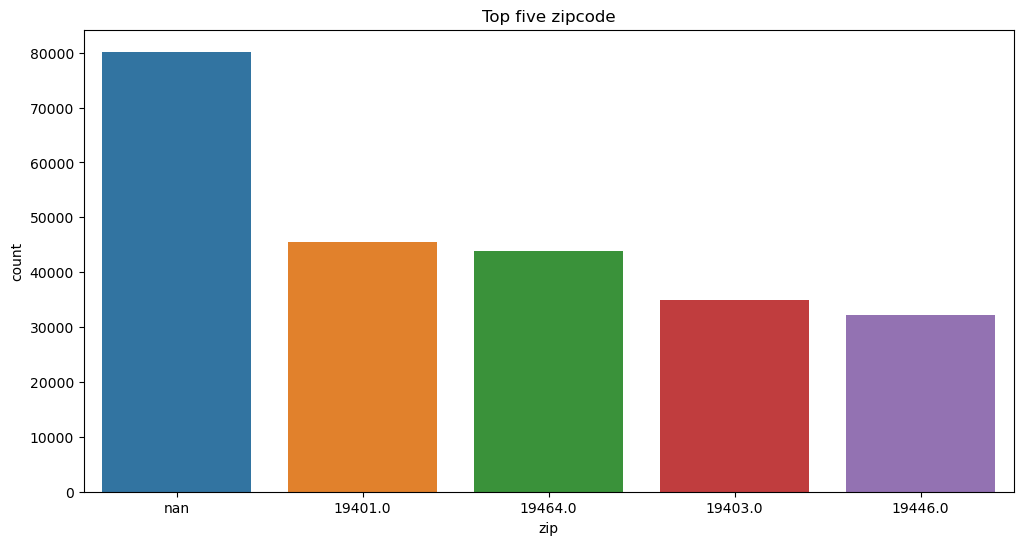

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(top_five_zipcodes, x = 'zip', y = 'count')
plt.ylabel('count')
plt.xlabel('zip')
plt.title('Top five zipcode')
plt.show()

**What are the top 5 townships (twp) for 911 calls?**

In [18]:
top_five_township = df['twp'].value_counts().nlargest(5).reset_index()
top_five_township

,twp,count
0,LOWER MERION,55470
1,ABINGTON,39927
2,NORRISTOWN,37616
3,UPPER MERION,35990
4,CHELTENHAM,30554


**Visualize top five township.**

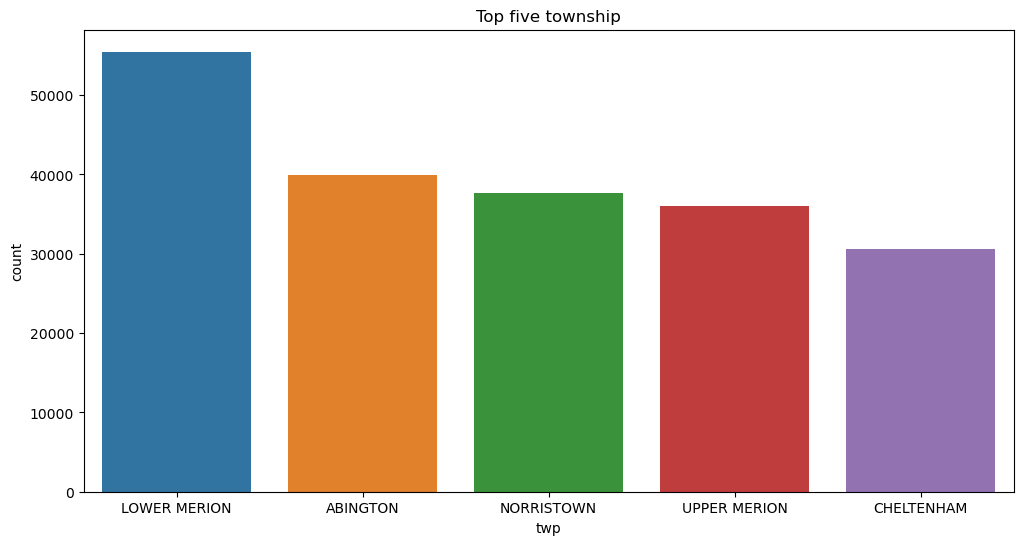

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(top_five_township, x = 'twp', y = 'count')
plt.ylabel('count')
plt.xlabel('twp')
plt.title('Top five township')
plt.show()

**Take a look at the 'title' column, how many unique title codes are there?**

In [20]:
#We have 148 unique title in the dataset.
unique_title = df['title'].nunique()
unique_title

148

### Section 3: Creating new features

In [21]:
#Overview of title column.
df['title'].sample(20)

14606                EMS: ABDOMINAL PAINS
17907         Traffic: VEHICLE ACCIDENT -
59834         Traffic: DISABLED VEHICLE -
496155        Traffic: VEHICLE ACCIDENT -
300277             Fire: WOODS/FIELD FIRE
361742        Traffic: VEHICLE ACCIDENT -
358060        Traffic: VEHICLE ACCIDENT -
634524                Fire: GAS-ODOR/LEAK
400793           EMS: MEDICAL ALERT ALARM
512095        Traffic: VEHICLE ACCIDENT -
477916                   EMS: FALL VICTIM
64201         Traffic: VEHICLE ACCIDENT -
184638                   EMS: FALL VICTIM
518693    Fire: S/B AT HELICOPTER LANDING
463917               EMS: NAUSEA/VOMITING
48753                    Fire: FIRE ALARM
153667            EMS: DIABETIC EMERGENCY
380437         EMS: RESPIRATORY EMERGENCY
576256                Fire: GAS-ODOR/LEAK
35800                    EMS: LACERATIONS
Name: title, dtype: object

In [22]:
#Create new column Reason using lambda funtion.
df['reason'] = df['title'].apply(lambda x: x.split(':')[0])
df['reason'].unique()

array(['EMS', 'Fire', 'Traffic'], dtype=object)

**What is the most common Reason for a 911 call based off of this new column?**

In [23]:
#implement value count to find common reason. 
reason_distribution = df['reason'].value_counts().reset_index()
reason_distribution

,reason,count
0,EMS,332591
1,Traffic,230115
2,Fire,100576


**Now use seaborn to create a countplot of 911 calls by Reason.**

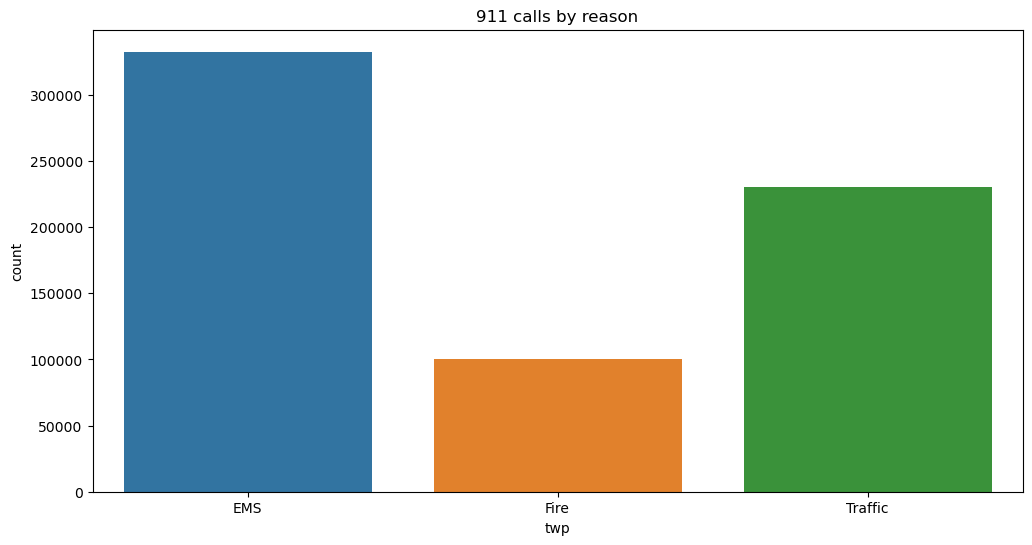

In [33]:
plt.figure(figsize=(12,6))
sns.countplot(data = df, x = 'reason')
plt.ylabel('count')
plt.xlabel('twp')
plt.title('911 calls by reason')
plt.show()

**911 calls by ordered reason**

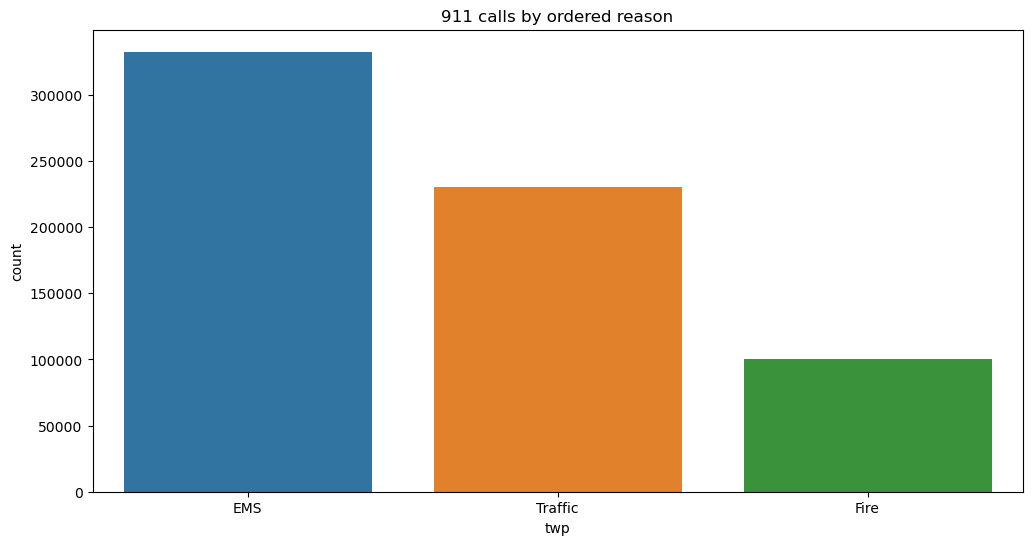

In [34]:
plt.figure(figsize=(12,6))
sns.barplot(reason_distribution, x = 'reason', y = 'count')
plt.ylabel('count')
plt.xlabel('twp')
plt.title('911 calls by ordered reason')
plt.show()

___
**Now let us begin to focus on time information. What is the data type of the objects in the timeStamp column?**

In [25]:
#timeStamp column is the datetime.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 663282 entries, 0 to 663521
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   lat        663282 non-null  float64       
 1   lng        663282 non-null  float64       
 2   desc       663282 non-null  object        
 3   zip        663282 non-null  object        
 4   title      663282 non-null  object        
 5   timeStamp  663282 non-null  datetime64[ns]
 6   twp        663282 non-null  object        
 7   addr       663282 non-null  object        
 8   e          663282 non-null  int64         
 9   reason     663282 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 55.7+ MB


In [26]:
#Create three columns Hour,Month,DayOfWeek.
df['timeStamp'].head(5)

0   2015-12-10 17:10:00
1   2015-12-10 17:29:00
2   2015-12-10 14:39:00
3   2015-12-10 16:47:00
4   2015-12-10 16:56:00
Name: timeStamp, dtype: datetime64[ns]

**Create column Hour.**

In [27]:
df['Hour'] = df['timeStamp'].apply(lambda x: x.hour)
#Preview hour column.
df['Hour'].head(5)

0    17
1    17
2    14
3    16
4    16
Name: Hour, dtype: int64

In [28]:
df['month'] = df['timeStamp'].apply(lambda x: x.month)
#Preview month column.
df['month']

0         12
1         12
2         12
3         12
4         12
          ..
663517     7
663518     7
663519     7
663520     7
663521     7
Name: month, Length: 663282, dtype: int64

**Notice how the Day of Week is an integer 0-6. Use the .map() with this dictionary to map the actual string names to the day of the week:**

    dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [29]:
dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
# First extract the day number, then map it to day name
df['DayOfWeek'] = df['timeStamp'].apply(lambda x: x.dayofweek).map(dmap)
df['DayOfWeek'].unique()

array(['Thu', 'Fri', 'Sat', 'Sun', 'Mon', 'Tue', 'Wed'], dtype=object)

**Create a new column month of the year like jan,feb etc...**

In [30]:
df['MonthOfYear'] = df['timeStamp'].apply(lambda x: x.strftime('%b'))
df['MonthOfYear'].unique() 

array(['Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug',
       'Sep', 'Oct', 'Nov'], dtype=object)

**Now use seaborn to create a countplot of the Day of Week column with the hue based off of the Reason column.**

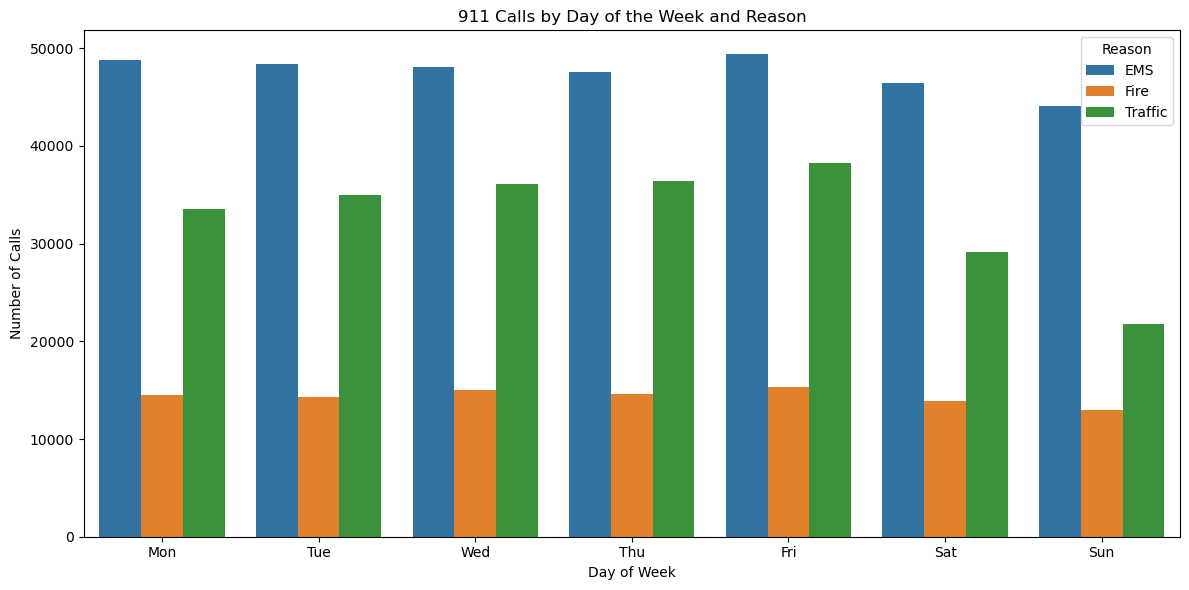

In [31]:
# Plot the grouped countplot
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
plt.figure(figsize=(12, 6))
sns.countplot(x= df['DayOfWeek'], data=df, hue='reason',order=day_order)

# Add some polish
plt.title('911 Calls by Day of the Week and Reason')
plt.xlabel('Day of Week')
plt.ylabel('Number of Calls')
plt.legend(title='Reason')
plt.tight_layout()
plt.show()

**Now do the same for Month:**

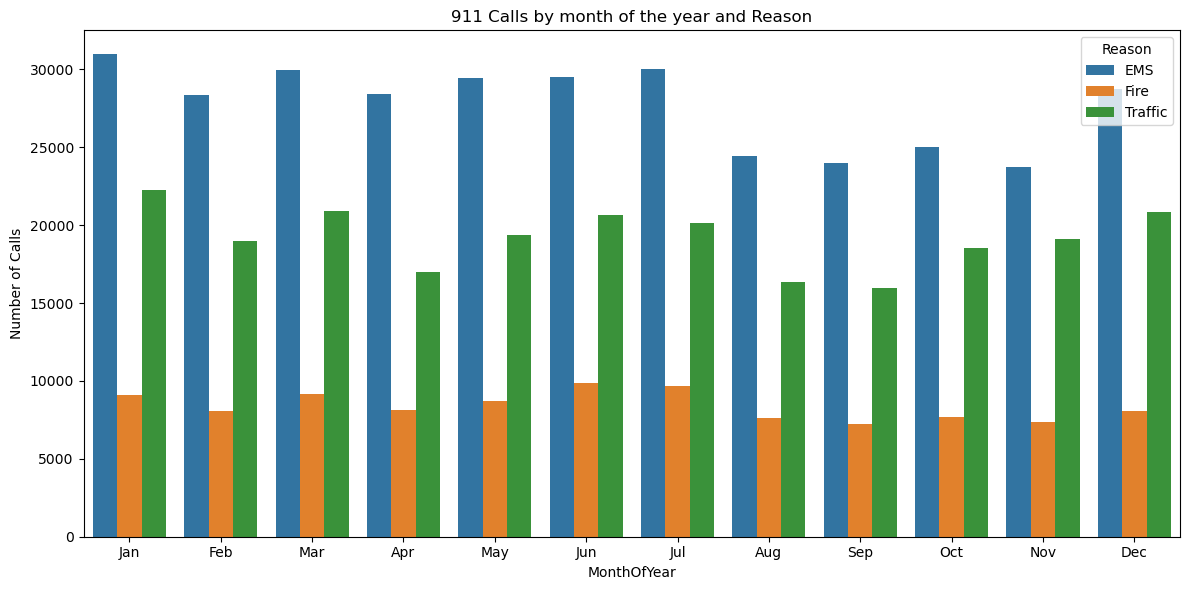

In [37]:
# Plot the grouped countplot for month of year.
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep','Oct', 'Nov', 'Dec']
plt.figure(figsize=(12, 6))
sns.countplot(x= df['MonthOfYear'], data=df, hue='reason',order= month_order)

# Add some polish
plt.title('911 Calls by month of the year and Reason')
plt.xlabel('MonthOfYear')
plt.ylabel('Number of Calls')
plt.legend(title='Reason')
plt.tight_layout()
plt.show()

**Now create a gropuby object called byMonth, where you group the DataFrame by the month column and use the count() method for aggregation. Use the head() method on this returned DataFrame.**

In [43]:
number_of_call_by_month = df['MonthOfYear'].value_counts().reset_index()
number_of_call_by_month

,MonthOfYear,count
0,Jan,62312
1,Jun,60020
2,Mar,60015
3,Jul,59823
4,Dec,57677
5,May,57488
6,Feb,55423
7,Apr,53560
8,Oct,51239
9,Nov,50176


**Now create a simple plot off of the dataframe indicating the count of calls per month.**

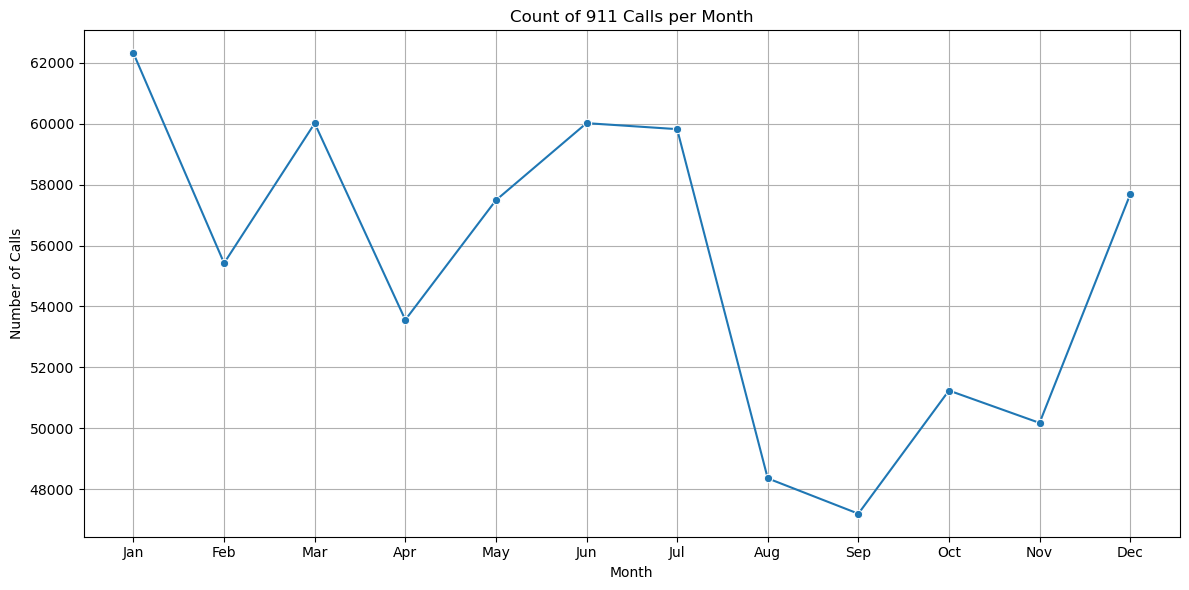

In [47]:
# Define the correct month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Sort the DataFrame by month_order
number_of_call_by_month['MonthOfYear'] = pd.Categorical(
    number_of_call_by_month['MonthOfYear'],
    categories=month_order,
    ordered=True
)
number_of_call_by_month = number_of_call_by_month.sort_values('MonthOfYear')

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=number_of_call_by_month, x='MonthOfYear', y='count', marker='o')
plt.title('Count of 911 Calls per Month')
plt.xlabel('Month')
plt.ylabel('Number of Calls')
plt.grid()
plt.tight_layout()
plt.show()

**Now see if you can use seaborn's lmplot() to create a linear fit on the number of calls per month. Keep in mind you may need to reset the index to a column.**

In [51]:
# Create a mapping dictionary
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5,
             'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10,
             'Nov': 11, 'Dec': 12}

# Map 'MonthOfYear' to numeric values
number_of_call_by_month['MonthNum'] = number_of_call_by_month['MonthOfYear'].map(month_map)


C:\Users\LUPHEN\AnacondaFile\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


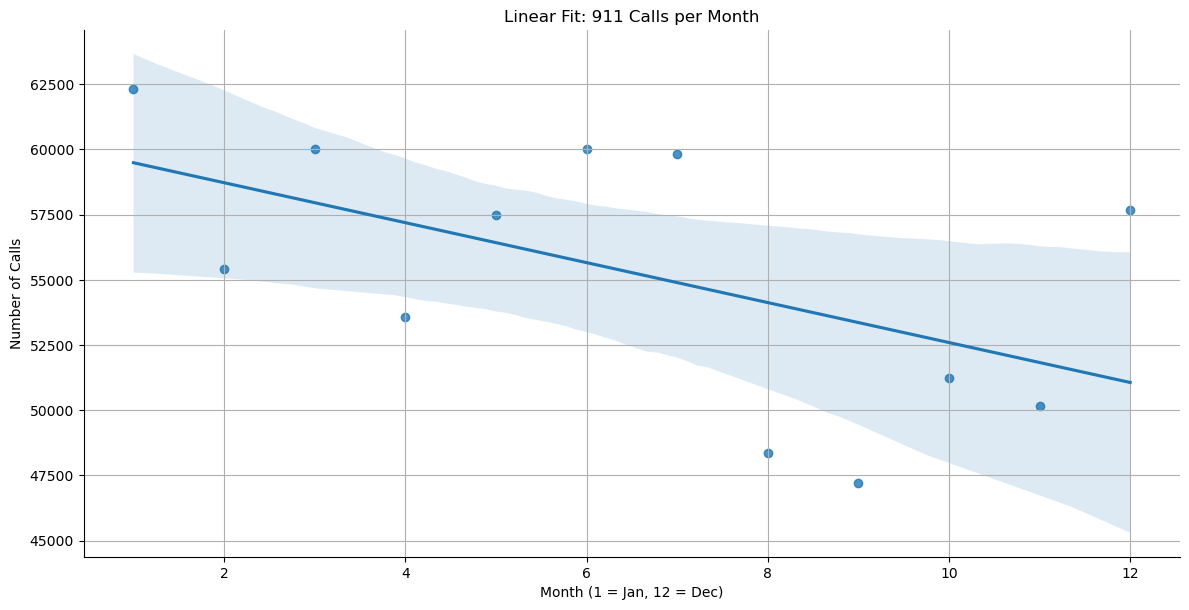

In [142]:
sns.lmplot(data=number_of_call_by_month, x='MonthNum', y='count', height=6, aspect=2)
plt.title('Linear Fit: 911 Calls per Month')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Number of Calls')
plt.grid(True)
#plt.tight_layout()
plt.show()

**Create a new column called 'Date' that contains the date from the timeStamp column. You'll need to use apply along with the .date() method.**

In [59]:
df['Date'] = df['timeStamp'].apply(lambda x: x.date())
df['Date'].unique

<bound method Series.unique of 0         2015-12-10
1         2015-12-10
2         2015-12-10
3         2015-12-10
4         2015-12-10
             ...    
663517    2020-07-29
663518    2020-07-29
663519    2020-07-29
663520    2020-07-29
663521    2020-07-29
Name: Date, Length: 663282, dtype: object>

**Create Year column**

In [63]:
df['Year'] = df['Date'].apply(lambda x: x.year)
df['Year']

0         2015
1         2015
2         2015
3         2015
4         2015
          ... 
663517    2020
663518    2020
663519    2020
663520    2020
663521    2020
Name: Year, Length: 663282, dtype: int64

In [79]:
year_by_call = df['Year'].value_counts().reset_index()
year_by_call

,Year,count
0,2018,151515
1,2019,148978
2,2016,142334
3,2017,140319
4,2020,72231
5,2015,7905


**Now groupby this Date column with the count() aggregate and create a plot of counts of 911 calls.**

In [75]:
# Group by Date and Reason, then count the number of calls
number_of_calls_by_date = df.groupby(['Date', 'reason']).size().reset_index(name='count')

# Sort to get the top 6 days with most calls (combined across all reasons)
top_calls_by_date = number_of_calls_by_date.sort_values('count', ascending=False).head(6)
top_calls_by_date

,Date,reason,count
2441,2018-03-02,Traffic,1328
3215,2018-11-15,Traffic,1324
4913,2020-06-03,Traffic,659
2456,2018-03-07,Traffic,586
2440,2018-03-02,Fire,568
134,2016-01-23,Traffic,531


**Now recreate this plot but create 3 separate plots with each plot representing a Reason for the 911 call**

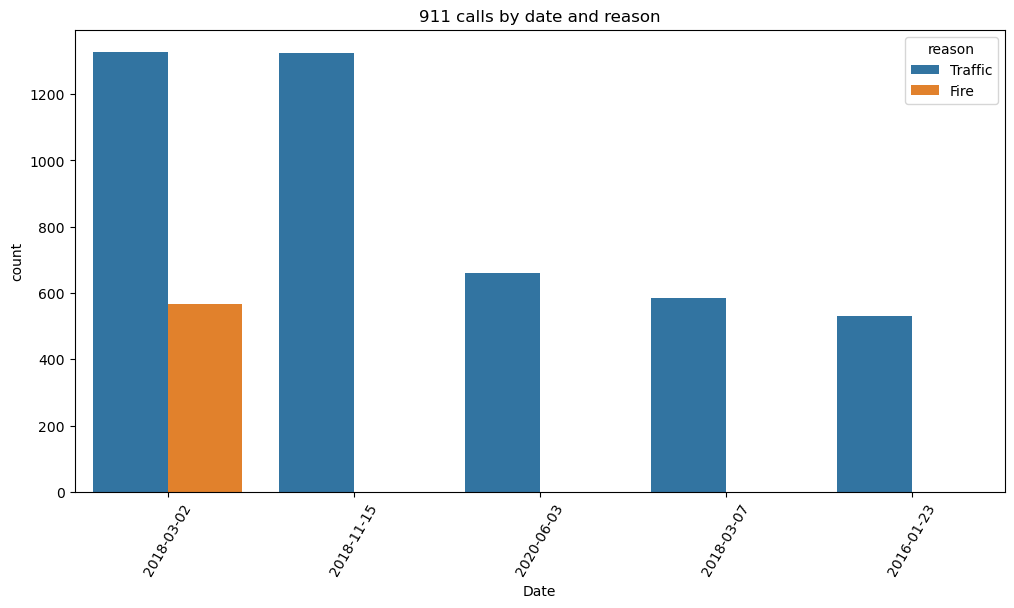

In [82]:
plt.figure(figsize=(12,6))
sns.barplot(top_calls_by_date, x = 'Date', y = 'count',hue = 'reason')
plt.ylabel('count')
plt.xlabel('Date')
plt.xticks(rotation=60)
plt.title('911 calls by date and reason')
plt.show()

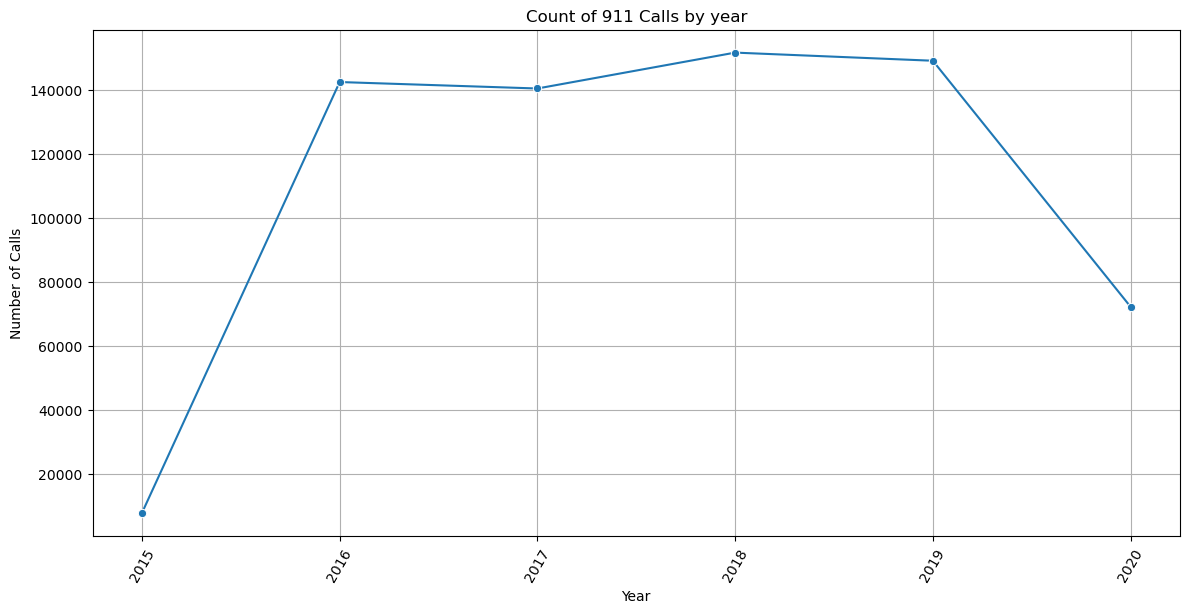

In [86]:
plt.figure(figsize=(12, 6))
sns.lineplot(year_by_call, x= 'Year', y='count', marker='o')
plt.title('Count of 911 Calls by year')
plt.xlabel('Year')
plt.ylabel('Number of Calls')
plt.grid()
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()

In [101]:
hours_day_of_week_count = df.groupby(['DayOfWeek','Hour']).size().unstack()
hours_day_of_week_count 

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
DayOfWeek,,,,,,,,,,,,,,,,,,,,,
Fri,1982,1634,1449,1295,1339,1638,2670,4143,5016,5288,...,6394,7040,7064,7108,5663,5055,4373,3913,3422,2834
Mon,1894,1571,1368,1272,1336,1844,2675,4430,5500,5724,...,5710,6287,6342,6408,5439,4487,3823,3253,2657,2071
Sat,2447,2059,1883,1592,1451,1580,1880,2488,3455,4313,...,5419,5181,5209,5209,4974,4752,4122,3892,3225,2965
Sun,2423,2134,1946,1613,1471,1488,1726,2408,2999,3728,...,4741,4473,4559,4500,4401,4134,3747,3160,2628,2323
Thu,1731,1406,1426,1235,1293,1775,2815,4432,5294,5410,...,6076,6490,6375,6932,5510,4703,4040,3487,2839,2354
Tue,1719,1459,1322,1213,1247,1740,2783,4420,5632,5563,...,5920,6247,6494,6881,5628,4621,3842,3409,2707,2137
Wed,1664,1483,1259,1265,1128,1609,2668,4642,5468,5444,...,6068,6530,6744,7049,5689,4686,4115,3535,2826,2206


**Now create a HeatMap using this new DataFrame.**

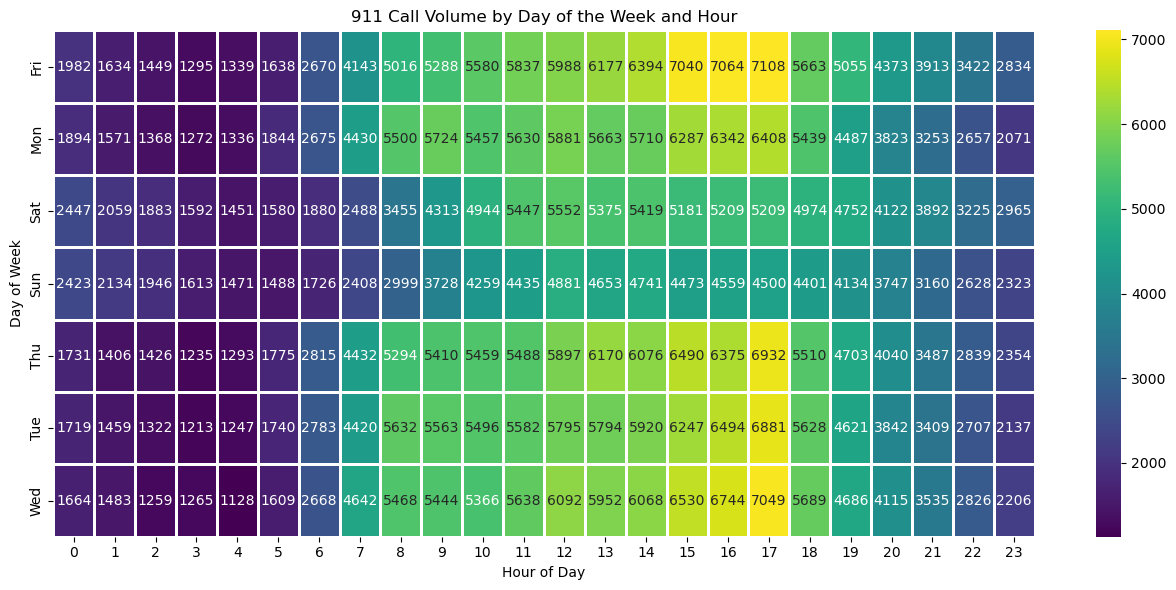

In [138]:
plt.figure(figsize=(13, 6))
sns.heatmap(hours_day_of_week_count,annot = True, cmap='viridis', linewidths=2.0, linecolor='white',fmt='d')
plt.title('911 Call Volume by Day of the Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

**Now create a clustermap using this DataFrame.**

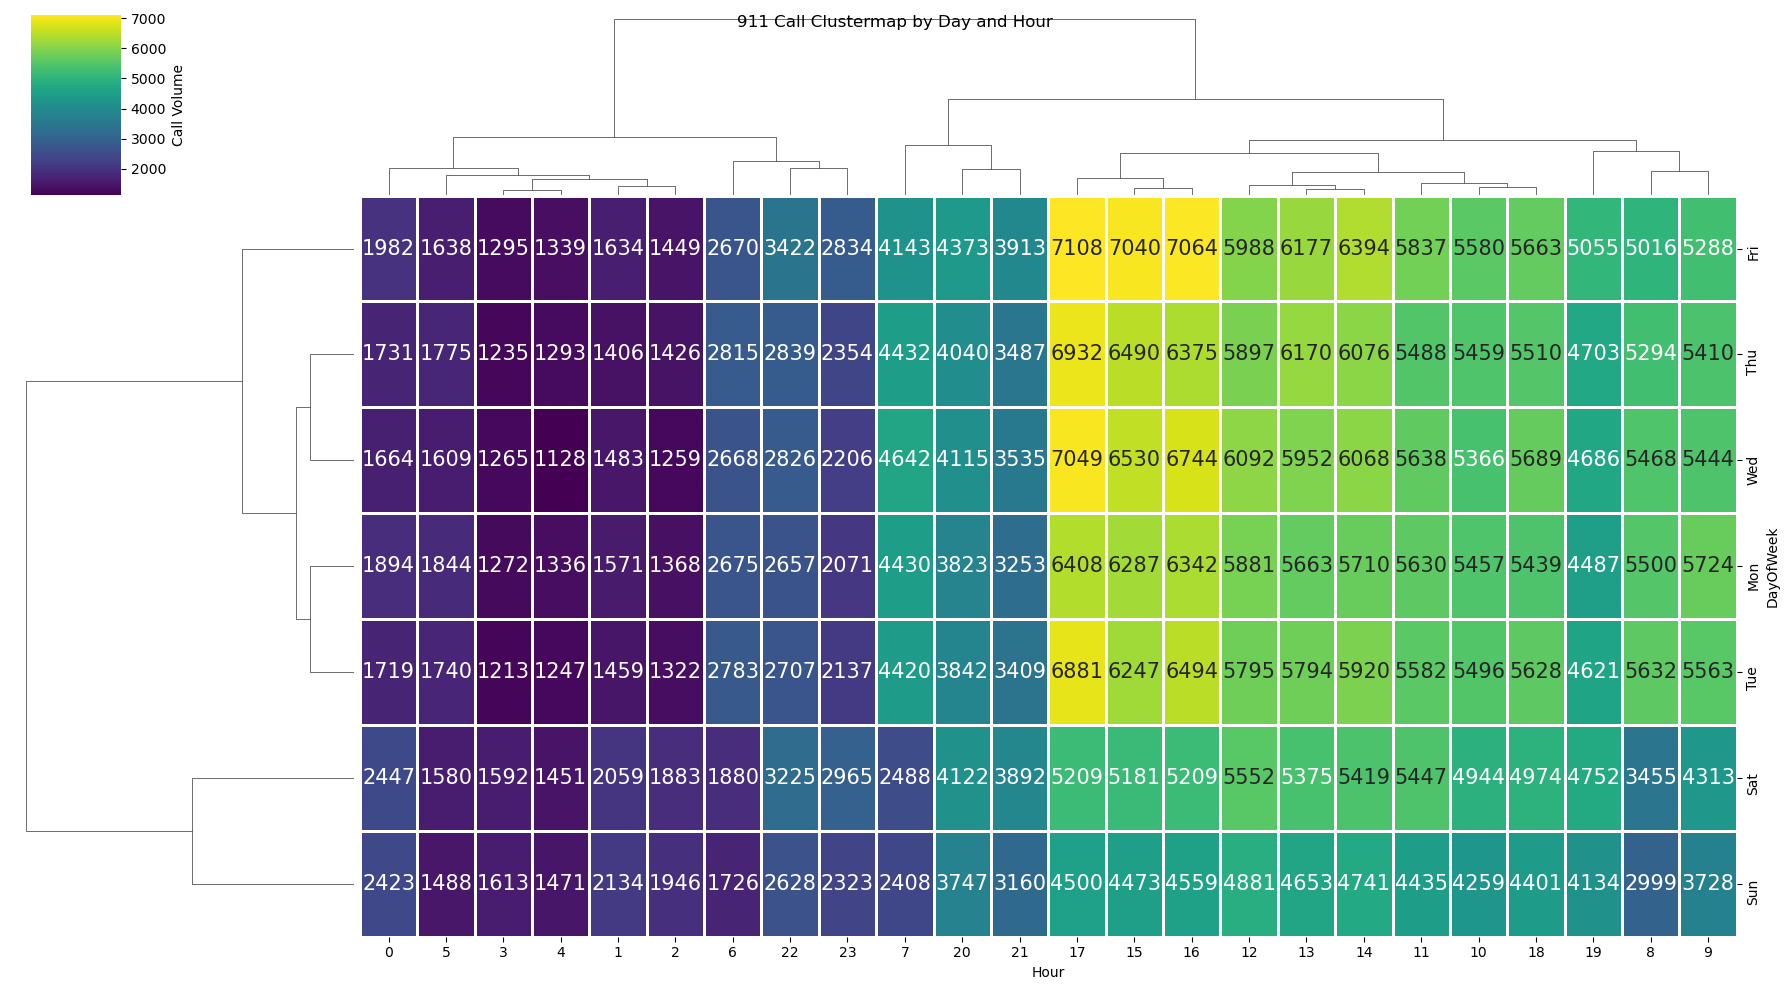

In [141]:
sns.clustermap(
   hours_day_of_week_count,
    cmap='viridis',           # Dark contrast for readability
    annot=True,            # Show numbers 
    fmt='d',               # Integer formatting
    linewidths=2,          # Thicker grid lines
    linecolor='white',     # Clean line contrast
    figsize=(18, 10),      # Bigger canvas for better layout
    cbar_kws={'label': 'Call Volume'},
    annot_kws={'size': 15}  # Adjust text size if needed
)
plt.suptitle('911 Call Clustermap by Day and Hour')
plt.show()


**Now repeat these same plots and operations, for a DataFrame that shows the Month as the column.**

In [132]:
month_of_week_count = df.groupby(['DayOfWeek','month']).size().unstack()
month_of_week_count 

month,1,2,3,4,5,6,7,8,9,10,11,12
DayOfWeek,,,,,,,,,,,,
Fri,9309,8255,10940,7968,8898,9203,8681,7336,7694,6934,8379,9305
Mon,8896,8747,8060,8401,7878,8509,9496,6853,6598,8074,6719,8491
Sat,8475,7592,8040,7496,7222,8196,7747,6111,6566,6609,6773,8587
Sun,7475,6452,6766,6849,6692,6837,7858,5275,5956,6316,5195,7159
Thu,9040,7997,8849,7701,8736,9489,8376,7506,6952,7482,8358,8151
Tue,9708,8087,8372,7545,9021,8346,9086,7290,6599,7948,7344,8305
Wed,9409,8293,8988,7600,9041,9440,8579,7984,6829,7876,7408,7679


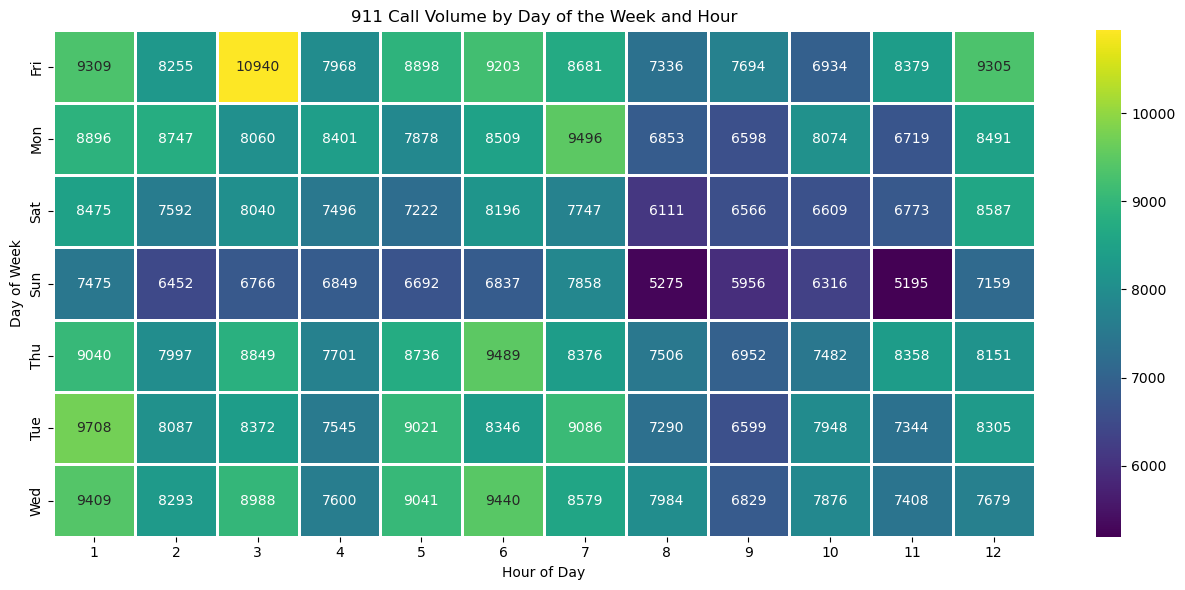

In [133]:
plt.figure(figsize=(13, 6))
sns.heatmap(month_of_week_count ,annot = True, cmap='viridis', linewidths=2.0, linecolor='white',fmt='d')
plt.title('911 Call Volume by Day of the Week and month')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

<Figure size 1300x600 with 0 Axes>

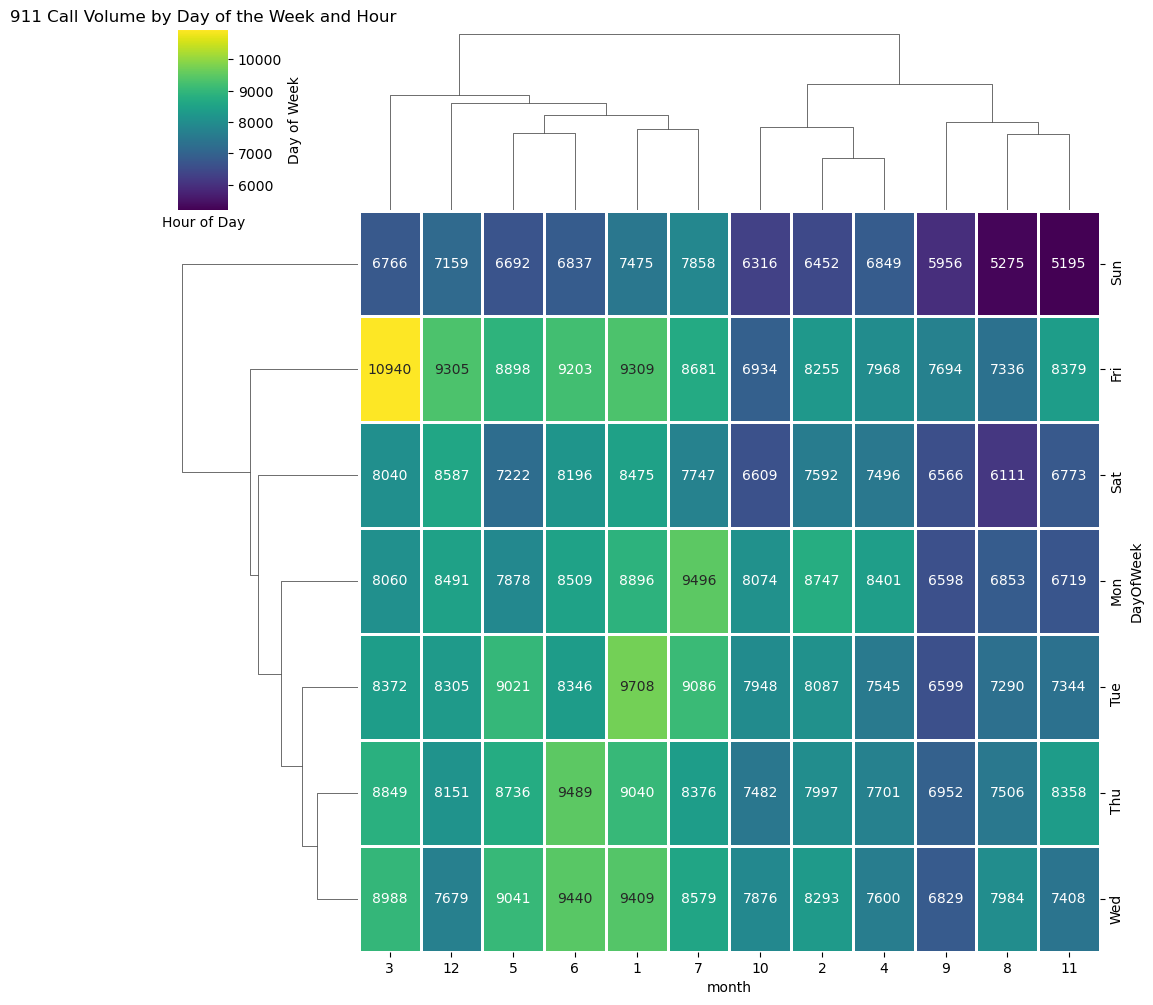

In [137]:
plt.figure(figsize=(13, 6))
sns.clustermap(month_of_week_count ,annot = True, cmap='viridis', linewidths=2.0, linecolor='white',fmt='d')
plt.title('911 Call Clustermap by Day of the Week and month')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()